conda env create -f environment.yml

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
ConfusionMatrixDisplay
)

RANDOM_STATE = 42

Langkah pertama adalah memuat seluruh library yang dibutuhkan seperti pandas dan numpy untuk manipulasi data, matplotlib dan seaborn untuk visualisasi, serta scikit-learn untuk pemodelan machine learning dan prepemrosesan data. Random state = 42 dideklarasikan supaya pengambilan data tetap konsisten setiap kali kode dijalankan.

In [2]:
df = pd.read_csv('data_customer_churn.csv')

Data pelanggan dimuat ke dalam struktur DataFrame menggunakan pandas, setelah diunduh dan ditempatkan di file customer_churn terlebih dahulu.

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

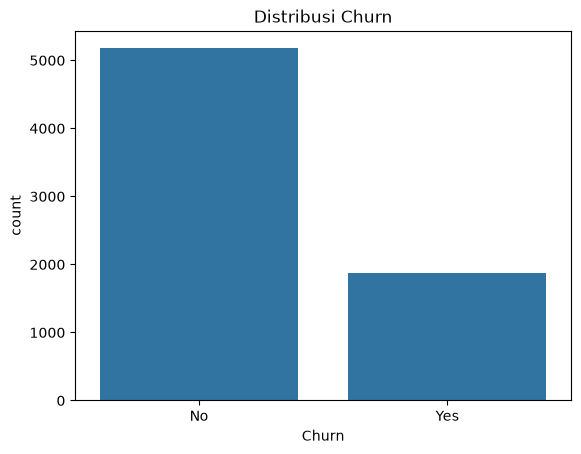

In [3]:
df.info()
df.describe()

print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

sns.countplot(x='Churn', data=df)
plt.title('Distribusi Churn')
plt.show()

.info() dan .describe() digunakan untuk melihat tipe data tiap kolom dan ringkasan statistik seperti rata-rata, nilai maksimum/minimum.
Analisis proporsi target (Churn) menunjukkan seberapa seimbang distribusi kelas pelanggan yang berhenti dan bertahan.


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())
df.dropna(subset=['TotalCharges'], inplace=True)

df.info()

11
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentM

Kolom TotalCharges terbaca sebagai teks atau string karena ada spasi kosong pada data yang hilang, sehingga harus dikonversi menjadi numerik dan baris yang kosong dibuang supaya tidak merusak model.

In [5]:
df = df.drop('customerID', axis=1)

X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1})

Menentukan fitur X dan target y. Kolom customerID dibuang karena merupakan pengenalan
unik yang tidak memiliki nilai prediktif terhadap perilaku churn.
Variabel target Churn dikonversi dari format teks ke format biner (1/0) supaya algoritma
machine learning dapat mengkalkulasinya secara matematis.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = RANDOM_STATE, stratify = y
)

Data dibagi menjadi 80% untuk training dan 20% untuk testing. Parameter stratify = y untuk memastikan proporsi kelas Churn dan No Churn pada data latih dan data uji tetap sama seperti proporsi dataset asli.

In [7]:
#identifikasi kolom
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']
nominal_features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

In [8]:
#bangun preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', OneHotEncoder(drop='if_binary'), binary_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_features)
    ]
)

StandarScaler digunakan untuk mengubah fitur numerik agar memiliki skala yang sama (rata-rata 0, standar deviasi 1) sehingga tidak ada fitur yang mendominasi.
One-Hot Encoding digunakan untuk mengubah fitur kategorikal (biner dan nominal) menjadi kolom biner (0/1). Semua proses digabungkan dalan ColumnTransformers agar transformasi berjalan otomatis dan seragam pada data latih dan data uji.

In [9]:
# cek hasil transformasi
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Shape data training setelah preprocessing:', X_train_processed.shape)

Shape data training setelah preprocessing: (5625, 40)


In [10]:
# logistic regression

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0))
])
logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

In [11]:
# decision tree

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5))
])
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

Model dilatih dengan dua metode berbeda menggunakan Pipeline. Pipeline digunakan untuk memastikan data yang masuk melewati proses prapemrosesan (preprocessor) sebelum masuk ke algoritma klasifikasi sehingga mencegah kebocoran data. Logistic Regression merupakan algoritma linier yang mengestimasi probabilitas churn. Decision Tree merupakan algoritma berbasis pohon keputusan dengan kedalaman maksimal 5 (dalam proyek ini) untuk mencegah model terlalu menghafal data latih (overfitting).

In [12]:
# Accuracy 

acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f'Accuracy Logistic Regression: {acc_logreg:.4f}')
print(f'Accuracy Decision Tree: {acc_dt:.4f}')

Accuracy Logistic Regression: 0.8045
Accuracy Decision Tree: 0.7896


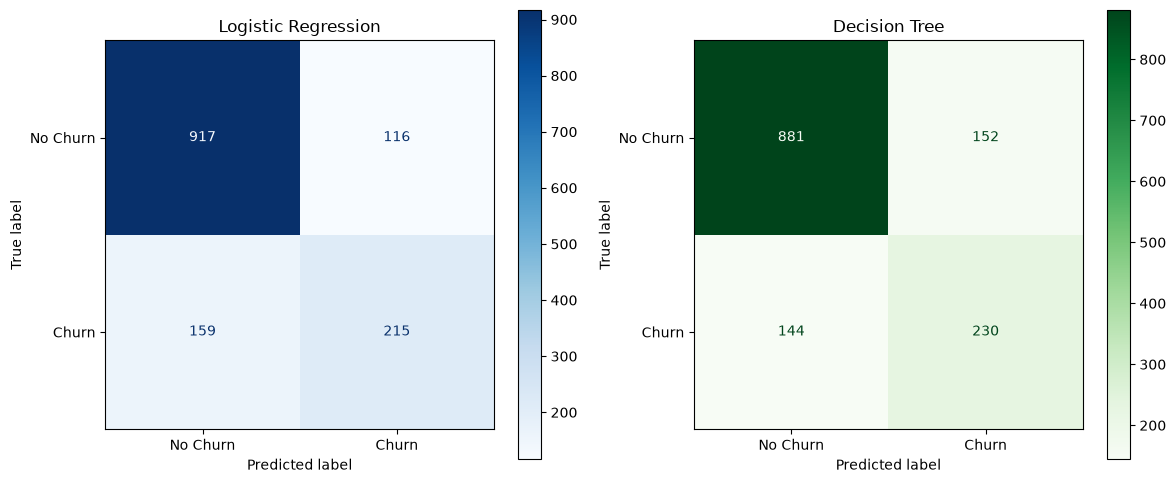

In [13]:
# confusion matrix

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_logreg),
display_labels=['No Churn', 'Churn']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
display_labels=['No Churn', 'Churn']).plot(ax=ax[1], cmap='Greens')
ax[1].set_title('Decision Tree')

plt.tight_layout()
plt.show()

In [14]:
#classification report
print('===Logistic Regression===')
print(classification_report(y_test, y_pred_logreg, target_names=['No Churn', 'Churn']))

print('\n===Decision Tree===')
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))


===Logistic Regression===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


===Decision Tree===
              precision    recall  f1-score   support

    No Churn       0.86      0.85      0.86      1033
       Churn       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



Selain mengukur akurasi, confusion matrix digunakan untuk memvisualisasikan seberapa banyak model salah menebak (melihat tingkat false positive dan false negative). Classification report digunakan untuk memberikan metrik esensial lain seperti precision, recall, dan f1-score untuk mengevaluasi keandalan model secara lebih komprehensif pada masing-masing kelas (0 dan 1).

In [15]:
# eksperimen a: One-Hot Encoding vs Label Encoding

from sklearn.preprocessing import OrdinalEncoder

label_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), 
        ('cat', OrdinalEncoder(), binary_features + nominal_features)
    ]
)

logreg_label = Pipeline([
    ('preprocessor', label_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
logreg_label.fit(X_train, y_train)
y_pred_label = logreg_label.predict(X_test)

print('One-Hot Accuracy:', acc_logreg)
print('Label Encoding Accuracy:', accuracy_score(y_test, y_pred_label))

One-Hot Accuracy: 0.8045486851457001
Label Encoding Accuracy: 0.7931769722814499


Membandingkan akurasi label/ordinal encoding dengan one hot encoding pada fitur kategorikal.
Logistic Regression memproses data secara matematis linier. One-Hot encoding lebih cocok karena mencegah model mengasumsikan adanya tingkatan antar kategori nominal. suatu kesalahan fatal yang akan terjadi jika memakai label encoding.

In [16]:
# eksperimen b: regularisasi logistic regression dengan C

for c in [0.001, 0.01, 0.1, 1, 10, 100]:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(C=c, max_iter=1000, random_state=RANDOM_STATE))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    print(f'C={c:>7} -> Accuracy={accuracy_score(y_test, pred):.4f}')

C=  0.001 -> Accuracy=0.7768
C=   0.01 -> Accuracy=0.7974
C=    0.1 -> Accuracy=0.8053
C=      1 -> Accuracy=0.8045
C=     10 -> Accuracy=0.8003
C=    100 -> Accuracy=0.7967


Menguji pengaruh berbagai nilai C pada algoritma logistic regression. 
Nilai C berbanding terbalik dengan regularisasi. C besar (100), regularisasinya lemah, model menjadi sangat kompleks dan memicu resiko overfitting. C kecil (0.001) regulasinya kuat, model ditekan menjadi terlalu sederhana sehingga memicu resiko underfitting.

In [17]:
# eksperiman c: kedalaman decision tree

for depth in [2, 3, 5, 10, 20, None]:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    print(f'max_depth={str(depth):>4} -> Accuracy={accuracy_score(y_test, pred):.4f}')

max_depth=   2 -> Accuracy=0.7520
max_depth=   3 -> Accuracy=0.7783
max_depth=   5 -> Accuracy=0.7896
max_depth=  10 -> Accuracy=0.7541
max_depth=  20 -> Accuracy=0.7356
max_depth=None -> Accuracy=0.7328


Mengevaluasi batasan kedalaman cabang pada decision tree. Underfitting terjadi ketika max_depth terlalu dangkal seperti 2 atau 3 sehingga model gagal menangkap kerumitan pola data. Overfitting terjadi ketika max_depth terlalu besar misal 20 atau none, sehingga model terlalu spesifik menghafal noise data latih yang menyebabkan penurunan akurasi pada data uji.

In [18]:
# eksperimen d: menangani ketidakseimbangan kelas

logreg_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])
logreg_balanced.fit(X_train, y_train)
y_pred_balanced = logreg_balanced.predict(X_test)

print('Tanpa balanced:', acc_logreg)
print('Dengan balanced:', accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Tanpa balanced: 0.8045486851457001
Dengan balanced: 0.7263681592039801
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



Menerapkan pembobotan kelas (class_weight='balanced') untuk mengatasi dominasi kelas No Churn.
Dalam kasus churn, mengurangi false negative (gagal mendeteksi pelanggan yang akan churn) lebih penting karena kehilangan pelanggan berdampak langsung pada hilangnya pendapatan rutin perusahaan, kerugian ini lebih besar dibandingkan biaya memberikan promo retensi pada pelanggan loyal (false positive)

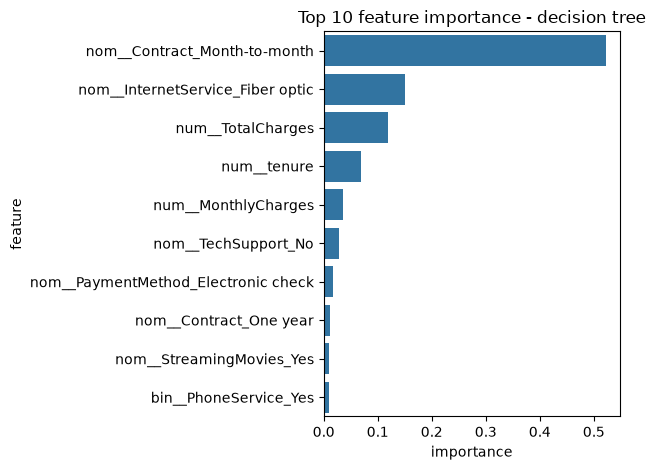

In [19]:
# eksperimen e: feature importance decision tree

dt_classifier = dt_pipeline.named_steps['classifier']
feature_names = dt_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False).head(10)

sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Top 10 feature importance - decision tree')
plt.tight_layout()
plt.show()

Eksperimen ini mengekstrak dan memvisualisasikan 10 fitur utama yang memiliki bobot terbesar (feature_importances_) dalam memengaruhi keputusan prediksi churn pada algoritma Decision Tree.
Tipe kontrak bulanan merupakan pemicu peling dominan yang menyebabkan pelanggan berhenti berlangganan, melampaui faktor lainnya seperti jenis internet(fiber optic) atau besaran tagihan. Strategi utama untuk mengurangi churn adalah membujuk pelanggan untuk beralih dari kontrak bulanan ke kontrak jangka panjang.

Model logistic regression dengan penanganan ketidakseimbangan kelas (class_weight='balanced') adalah model terbaik untuk kasus ini. Walaupun akurasi keseluruhan menuruh yakni dari 0.8045 menjadi 0.7263, model ini lebih baik dalam menangkap pelanggan yang berisiko keluar dengan peningkatan metrik recall kelas churn menjadi 0.80. Dalam analisis churn meminimalisir kegagalan mendeteksi pelanggan yang akan pergi atau false negative jauh lebih penting karena berdampak langsung pada pendapatan perusahaan, dan kerugian ini lebih besar dibanding membari promosi kepada pelanggan yang diprediksi salah (false positive).